In [7]:
import os
import re
import glob
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
from PIL import Image
from torchvision import transforms, models
from tqdm import tqdm
import matplotlib.pyplot as plt

os.makedirs("output", exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[*] Running on device: {device}")

[*] Running on device: cuda


In [8]:
import os
import glob
import pandas as pd
from sklearn.model_selection import GroupKFold

# 1. Automatically find where the images are located under /kaggle/input
print("[*] Locating images in Kaggle input directory...")
all_pngs = glob.glob("/kaggle/input/**/*.png", recursive=True)

if not all_pngs:
    raise FileNotFoundError("No PNG images found! Check the right sidebar to ensure the dataset is attached.")

print(f"[+] Found {len(all_pngs)} total images. Parsing filenames...")

def parse_breakhis_filename(filepath):
    filename = os.path.basename(filepath)
    tokens = filename.replace(".png", "").split("-")
    if len(tokens) >= 4:
        # 'M' for malignant (1), 'B' for benign (0)
        class_type = 1 if "_M_" in tokens[0] else 0
        patient_id = f"{tokens[1]}-{tokens[2]}"
        mag = tokens[3]
        return {
            "filepath": filepath,
            "label": class_type,
            "patient_id": patient_id,
            "magnification": f"{mag}X"
        }
    return None

records = [parse_breakhis_filename(p) for p in all_pngs]
records = [r for r in records if r is not None]
df = pd.DataFrame(records)

print(f"[+] Successfully loaded {len(df)} images across {df['patient_id'].nunique()} patients.")

# 2. Patient-stratified 5-Fold split (GroupKFold prevents patient leakage)
gkf = GroupKFold(n_splits=5)
df["fold"] = -1
for fold_idx, (_, val_idx) in enumerate(gkf.split(df, df["label"], groups=df["patient_id"])):
    df.loc[val_idx, "fold"] = fold_idx

print(f"[+] Fold assignment complete. Class counts:")
print(df["label"].value_counts().rename({0: "Benign", 1: "Malignant"}))

[*] Locating images in Kaggle input directory...
[+] Found 7909 total images. Parsing filenames...
[+] Successfully loaded 7909 images across 81 patients.
[+] Fold assignment complete. Class counts:
label
Malignant    5429
Benign       2480
Name: count, dtype: int64


In [9]:
# Backbone: Pretrained ResNet-50 truncated before final classification layer
backbone = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
backbone = nn.Sequential(*list(backbone.children())[:-1]).to(device)
backbone.eval()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def extract_patches_and_embed(image_path, patch_size=224):
    """Tiles a 700x460 histopathology image into non-overlapping patches and extracts features."""
    img = Image.open(image_path).convert("RGB")
    w, h = img.size
    
    patches = []
    # Grid tile extraction
    for top in range(0, h - patch_size + 1, patch_size):
        for left in range(0, w - patch_size + 1, patch_size):
            patch = img.crop((left, top, left + patch_size, top + patch_size))
            patches.append(transform(patch))
            
    if not patches:
        patches.append(transform(img))
        
    patch_tensor = torch.stack(patches).to(device) # (K, 3, 224, 224)
    with torch.no_grad():
        features = backbone(patch_tensor).squeeze(-1).squeeze(-1) # (K, 2048)
    return features.cpu()

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 220MB/s]


In [10]:
class GatedAttentionMIL(nn.Module):
    def __init__(self, in_features=2048, hidden_dim=256, num_classes=2, dropout=0.25):
        super(GatedAttentionMIL, self).__init__()
        self.projector = nn.Sequential(
            nn.Linear(in_features, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.attention_V = nn.Sequential(nn.Linear(hidden_dim, 128), nn.Tanh())
        self.attention_U = nn.Sequential(nn.Linear(hidden_dim, 128), nn.Sigmoid())
        self.attention_w = nn.Linear(128, 1)
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, h):
        # h shape: (K, 2048) -> Bag of K patch features
        h = self.projector(h)
        a_v = self.attention_V(h)
        a_u = self.attention_U(h)
        a = self.attention_w(a_v * a_u)
        A = F.softmax(a, dim=0) # Normalized attention scores (K, 1)
        z = torch.mm(A.T, h)    # Aggregated bag representation (1, hidden_dim)
        logits = self.classifier(z)
        return logits, A

In [11]:
train_df = df[df["fold"] != 0].reset_index(drop=True)
val_df = df[df["fold"] == 0].reset_index(drop=True)

model = GatedAttentionMIL().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

print(f"[*] Training on {len(train_df)} bags, Validating on {len(val_df)} bags...")

for epoch in range(1, 11):
    model.train()
    train_loss = 0.0
    
    # Train epoch (sample bags)
    for _, row in train_df.sample(frac=0.3, random_state=epoch).iterrows():
        bag = extract_patches_and_embed(row["filepath"]).to(device)
        label = torch.tensor([row["label"]]).to(device)
        
        optimizer.zero_grad()
        logits, _ = model(bag)
        loss = criterion(logits, label)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        
    # Validation
    model.eval()
    val_preds, val_targets = [], []
    with torch.no_grad():
        for _, row in val_df.sample(n=100, random_state=42).iterrows():
            bag = extract_patches_and_embed(row["filepath"]).to(device)
            logits, _ = model(bag)
            pred = torch.argmax(logits, dim=1).item()
            val_preds.append(pred)
            val_targets.append(row["label"])
            
    acc = accuracy_score(val_targets, val_preds)
    f1 = f1_score(val_targets, val_preds, average="macro")
    print(f"Epoch {epoch:02d} | Train Loss: {train_loss/len(train_df):.4f} | Val Acc: {acc:.4f} | Val Macro-F1: {f1:.4f}")

[*] Training on 6337 bags, Validating on 1572 bags...
Epoch 01 | Train Loss: 0.1055 | Val Acc: 0.7800 | Val Macro-F1: 0.7800
Epoch 02 | Train Loss: 0.0740 | Val Acc: 0.8100 | Val Macro-F1: 0.7951
Epoch 03 | Train Loss: 0.0570 | Val Acc: 0.8200 | Val Macro-F1: 0.8140
Epoch 04 | Train Loss: 0.0480 | Val Acc: 0.8200 | Val Macro-F1: 0.8188
Epoch 05 | Train Loss: 0.0409 | Val Acc: 0.8000 | Val Macro-F1: 0.7947
Epoch 06 | Train Loss: 0.0374 | Val Acc: 0.8100 | Val Macro-F1: 0.8077
Epoch 07 | Train Loss: 0.0288 | Val Acc: 0.7400 | Val Macro-F1: 0.7400
Epoch 08 | Train Loss: 0.0309 | Val Acc: 0.8500 | Val Macro-F1: 0.8465
Epoch 09 | Train Loss: 0.0341 | Val Acc: 0.7800 | Val Macro-F1: 0.7640
Epoch 10 | Train Loss: 0.0274 | Val Acc: 0.8200 | Val Macro-F1: 0.8174


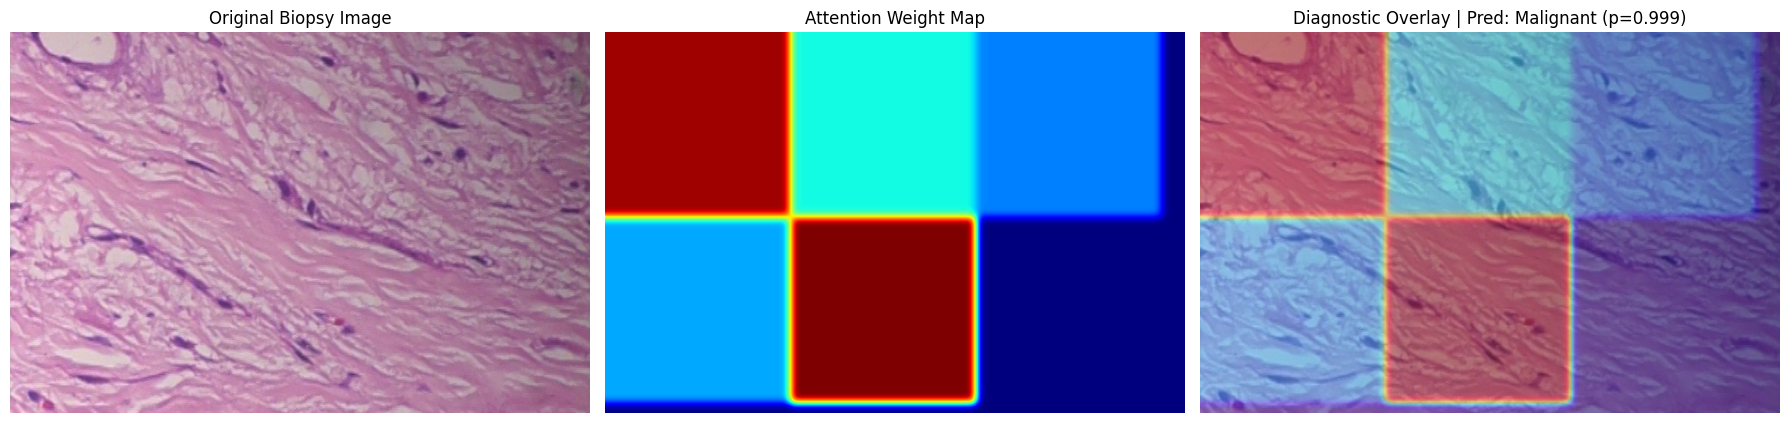

In [12]:
import cv2
import matplotlib.pyplot as plt

def generate_mil_heatmap(model, image_path, patch_size=224):
    model.eval()
    img = Image.open(image_path).convert("RGB")
    w, h = img.size
    
    patches, coords = [], []
    for top in range(0, h - patch_size + 1, patch_size):
        for left in range(0, w - patch_size + 1, patch_size):
            patch = img.crop((left, top, left + patch_size, top + patch_size))
            patches.append(transform(patch))
            coords.append((left, top))
            
    patch_tensor = torch.stack(patches).to(device)
    with torch.no_grad():
        features = backbone(patch_tensor).squeeze(-1).squeeze(-1)
        logits, attention = model(features)
        
    attn_weights = attention.squeeze().cpu().numpy()
    norm_attn = (attn_weights - attn_weights.min()) / (attn_weights.max() - attn_weights.min() + 1e-8)
    
    # Heatmap Canvas
    heatmap_canvas = np.zeros((h, w), dtype=np.float32)
    for (x, y), score in zip(coords, norm_attn):
        heatmap_canvas[y:y+patch_size, x:x+patch_size] = score
        
    heatmap_canvas = cv2.GaussianBlur(heatmap_canvas, (31, 31), 0)
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_canvas), cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    
    # Blend with original
    orig_np = np.array(img)
    blended = cv2.addWeighted(orig_np, 0.6, heatmap_color, 0.4, 0)
    
    pred_label = "Malignant" if torch.argmax(logits, dim=1).item() == 1 else "Benign"
    prob = torch.softmax(logits, dim=1)[0, 1].item()
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes[0].imshow(orig_np)
    axes[0].set_title("Original Biopsy Image")
    axes[0].axis("off")
    
    axes[1].imshow(heatmap_canvas, cmap="jet")
    axes[1].set_title("Attention Weight Map")
    axes[1].axis("off")
    
    axes[2].imshow(blended)
    axes[2].set_title(f"Diagnostic Overlay | Pred: {pred_label} (p={prob:.3f})")
    axes[2].axis("off")
    
    plt.tight_layout()
    plt.savefig("output/sample_attention_heatmap.png", dpi=300)
    plt.show()

# Run on a sample malignant slide from the validation set
sample_malignant = val_df[val_df["label"] == 1].iloc[0]["filepath"]
generate_mil_heatmap(model, sample_malignant)

In [13]:
torch.save(model.state_dict(), "output/gated_attention_mil_breakhis.pt")
df.to_csv("output/patient_splits.csv", index=False)
print("[+] Model weights and patient split manifest exported to output/ folder.")

[+] Model weights and patient split manifest exported to output/ folder.
